## Procedimiento de modelado para secuencias temporales

### Preparacion de datos

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, losses, metrics, callbacks

(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.]),
 [Text(-10.0, 0, '2020-03-01'),
  Text(0.0, 0, '2020-01-24'),
  Text(10.0, 0, '2020-02-03'),
  Text(20.0, 0, '2020-02-13'),
  Text(30.0, 0, '2020-02-23'),
  Text(40.0, 0, '2020-03-04'),
  Text(50.0, 0, '')])

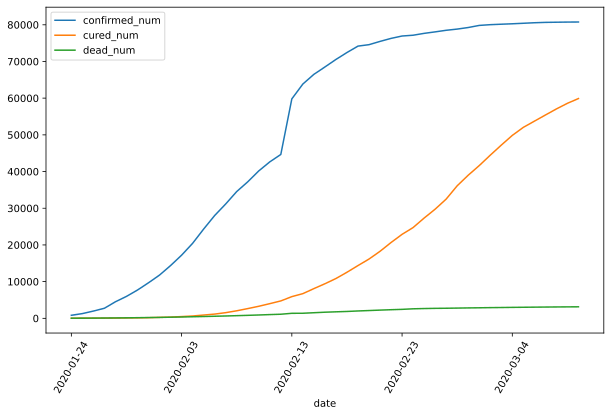

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

df = pd.read_csv('../data/covid-19.csv', sep="\t")
df.plot(x='date', y=["confirmed_num", "cured_num", "dead_num"], figsize=(10, 6))
plt.xticks(rotation=60)

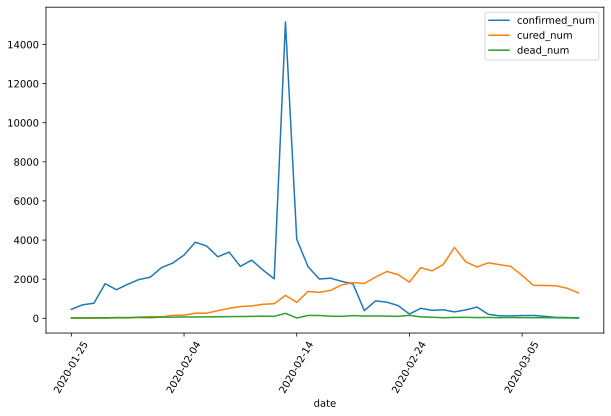

In [3]:
dfdata = df.set_index("date")
dfdiff = dfdata.diff(periods=1).dropna()
dfdiff = dfdiff.reset_index("date")

dfdiff.plot(x="date", y=["confirmed_num", "cured_num", "dead_num"], figsize=(10, 6))
plt.xticks(rotation=60)
dfdiff = dfdiff.drop("date", axis=1).astype("float32")

In [4]:
WINDOW_SIZE = 8

def batch_dataset(dataset):
    dataset_batched = dataset.batch(WINDOW_SIZE, drop_remainder=True)
    return dataset_batched

ds_data = tf.data.Dataset.from_tensor_slices(tf.constant(dfdiff.values, dtype=tf.float32))\
        .window(WINDOW_SIZE, shift=1).flat_map(batch_dataset)

ds_label = tf.data.Dataset.from_tensor_slices(tf.constant(dfdiff.values[WINDOW_SIZE:], dtype=tf.float32))

ds_train = tf.data.Dataset.zip((ds_data, ds_label)).batch(38).cache()
        

2021-12-23 20:23:19.937897: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-12-23 20:23:19.938473: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


### Definicion de modelo

In [5]:
class Block(layers.Layer):
    def __init__(self, **kwargs):
        super(Block, self).__init__(**kwargs)
        
    def call(self, x_input, x):
        x_out = tf.maximum((1 + x) * x_input[:, -1, :], 0.0)
        return x_out
    
    def get_config(self):
        config = super(Block, self).get_config()
        return config

In [6]:
tf.keras.backend.clear_session()
x_input = layers.Input(shape = (None,3),dtype = tf.float32)
x = layers.LSTM(3,return_sequences = True,input_shape=(None,3))(x_input)
x = layers.LSTM(3,return_sequences = True,input_shape=(None,3))(x)
x = layers.LSTM(3,return_sequences = True,input_shape=(None,3))(x)
x = layers.LSTM(3,input_shape=(None,3))(x)
x = layers.Dense(3)(x)

x = Block()(x_input,x)
model = models.Model(inputs = [x_input],outputs = [x])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, 3)]    0           []                               
                                                                                                  
 lstm (LSTM)                    (None, None, 3)      84          ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, None, 3)      84          ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, None, 3)      84          ['lstm_1[0][0]']                 
                                                                                              

### Entrenamiento del modelo

In [7]:
class MSPE(losses.Loss):
    def call(self, y_true, y_pred):
        err_percent = (y_true - y_pred) ** 2 / (tf.maximum(y_true ** 2, 1e-7))
        mean_error_percent = tf.reduce_mean(err_percent)
        return mean_error_percent
    
    def get_config(self):
        config = super(MSPE, self).get_config()
        return config

In [8]:
import os
import datetime
from pathlib import Path

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss=MSPE(name="MSPE"))
stamp = datetime.datetime.now().strftime("%Y%m%d - %H%M%S")
logdir = str(Path('../data/autograph/' + stamp))

tb_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5, patience=100)
stop_callback = tf.keras.callbacks.EarlyStopping(monitor="loss", patience=200)
callbacks_list = [tb_callback, lr_callback, stop_callback]
history = model.fit(ds_train, epochs=500, callbacks=callbacks_list)

Epoch 1/500
1/1 [==============================] - 4s 4s/step - loss: 3.1649 - lr: 0.0100
Epoch 2/500
1/1 [==============================] - 0s 41ms/step - loss: 2.8831 - lr: 0.0100
Epoch 3/500
1/1 [==============================] - 0s 40ms/step - loss: 2.5770 - lr: 0.0100
Epoch 4/500
1/1 [==============================] - 0s 40ms/step - loss: 2.2492 - lr: 0.0100
Epoch 5/500
1/1 [==============================] - 0s 42ms/step - loss: 1.9064 - lr: 0.0100
Epoch 6/500
1/1 [==============================] - 0s 40ms/step - loss: 1.5594 - lr: 0.0100
Epoch 7/500
1/1 [==============================] - 0s 41ms/step - loss: 1.2249 - lr: 0.0100
Epoch 8/500
1/1 [==============================] - 0s 41ms/step - loss: 0.9244 - lr: 0.0100
Epoch 9/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6817 - lr: 0.0100
Epoch 10/500
1/1 [==============================] - 0s 40ms/step - loss: 0.5183 - lr: 0.0100
Epoch 11/500
1/1 [==============================] - 0s 41ms/step - loss: 0.4460 -

### Evaluacion del modelo

In [11]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib.pyplot as plt

def plot_metric(history, metric):
    train_metrics = history.history[metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, 'bo--')
    plt.title('Training '+ metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_"+metric])
    plt.show()

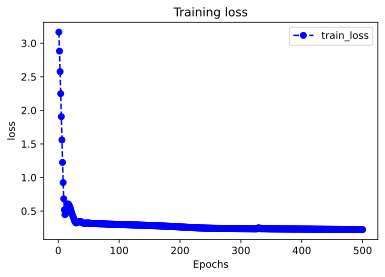

In [12]:
plot_metric(history,"loss")